# Fraud Detection – Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the IEEE-CIS Fraud Detection dataset.

The goal is to understand the structure of the data, identify patterns, detect issues such as missing values and imbalance, and prepare insights for preprocessing and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.rcParams['figure.figsize'] = (12, 8)

## Data Loading and Merging

In this step, we load the transaction and identity datasets and merge them using the TransactionID.

This ensures that all relevant features are combined into a single dataset for analysis.

In [2]:
train_trans = pd.read_csv("../data/raw/train_transaction.csv")
train_id = pd.read_csv("../data/raw/train_identity.csv")

print("Transaction shape:", train_trans.shape)
print("Identity shape:", train_id.shape)

df = train_trans.merge(train_id, on="TransactionID", how="left")

print("Data Loaded Successfully!")
print("Merged shape:", df.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)
Data Loaded Successfully!
Merged shape: (590540, 434)


## Initial Data Exploration

We examine:
- The first few rows of the dataset
- Data types of each feature
- Basic statistical summary

This helps us understand the structure and scale of the data.

In [3]:
display(df.head())
print("="*50)
df.info()
print("="*50)
display(df.describe(include='all'))

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540,590540.000000,581607.000000,588975.000000,588963,586281.000000,...,140282,77586.000000,73289,77805,140985,140985,140985,140985,140810,118666
unique,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,4,NaN,...,130,NaN,260,4,2,2,2,2,2,1786
top,NaN,NaN,NaN,NaN,W,NaN,NaN,NaN,visa,NaN,...,chrome 63.0,NaN,1920x1080,match_status:2,T,F,T,F,desktop,Windows
freq,NaN,NaN,NaN,NaN,439670,NaN,NaN,NaN,384767,NaN,...,22000,NaN,16874,60011,77814,134066,110452,73922,85165,47722
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,NaN,9898.734658,362.555488,153.194925,NaN,199.278897,...,NaN,26.508597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.704744e+05,0.183755,4.617224e+06,239.162522,NaN,4901.170153,157.793246,11.336444,NaN,41.244453,...,NaN,3.737502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.987000e+06,0.000000,8.640000e+04,0.251000,NaN,1000.000000,100.000000,100.000000,NaN,100.000000,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,NaN,6019.000000,214.000000,150.000000,NaN,166.000000,...,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,NaN,9678.000000,361.000000,150.000000,NaN,226.000000,...,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,NaN,14184.000000,512.000000,150.000000,NaN,226.000000,...,NaN,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Target Variable Analysis (isFraud)

We analyze the distribution of the target variable to understand class balance.

This is important because fraud detection datasets are usually highly imbalanced.

In [4]:
print("Value counts:")
print(df['isFraud'].value_counts())
print("\nNormalized:")
print(df['isFraud'].value_counts(normalize=True))

Value counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Normalized:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


## Fraud Distribution Visualization

This plot shows the number of fraudulent vs. non-fraudulent transactions.

Observation:
The dataset is highly imbalanced, with fraudulent transactions representing a tiny percentage of the data.

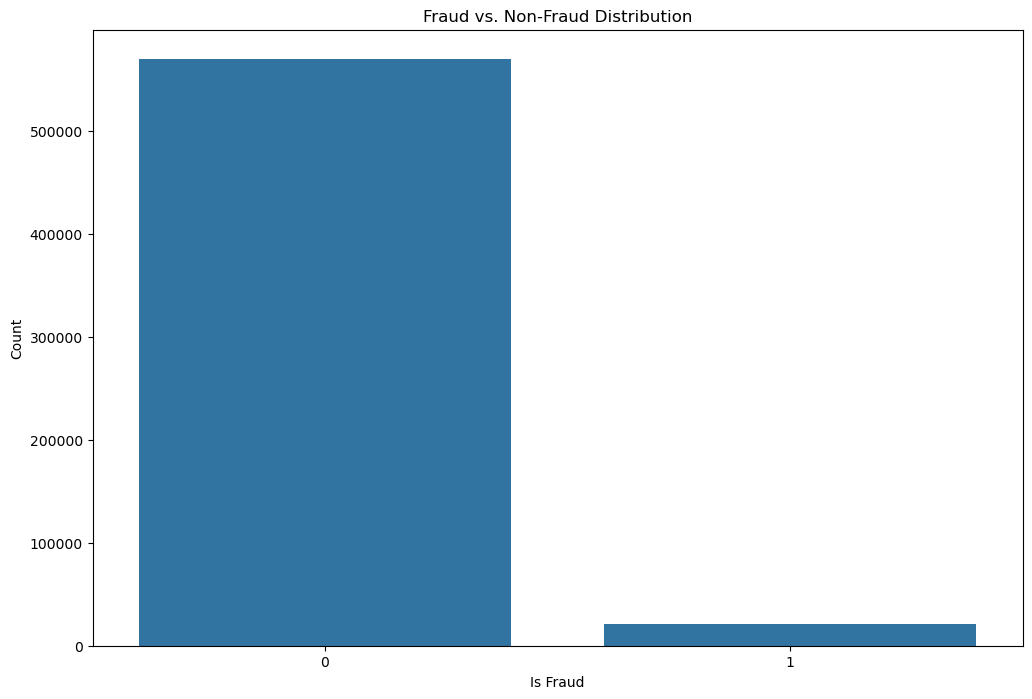

In [5]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs. Non-Fraud Distribution")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

## Missing Values Analysis

We calculate the percentage of missing values for each feature.

This helps identify:
- Features that may need imputation
- Features that may be dropped due to excessive missing values

In [6]:
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending=False)

display(missing_df.head(20))

,missing_percent
id_24,99.196159
id_25,99.130965
id_07,99.127070
id_08,99.127070
id_21,99.126393
id_26,99.125715
id_27,99.124699
id_23,99.124699
id_22,99.124699
dist2,93.628374


## Top Features with Missing Values

This visualization shows the top 20 features with the highest percentage of missing values.

Observation:
Many features contain a large number of missing values, which will require careful handling during preprocessing.

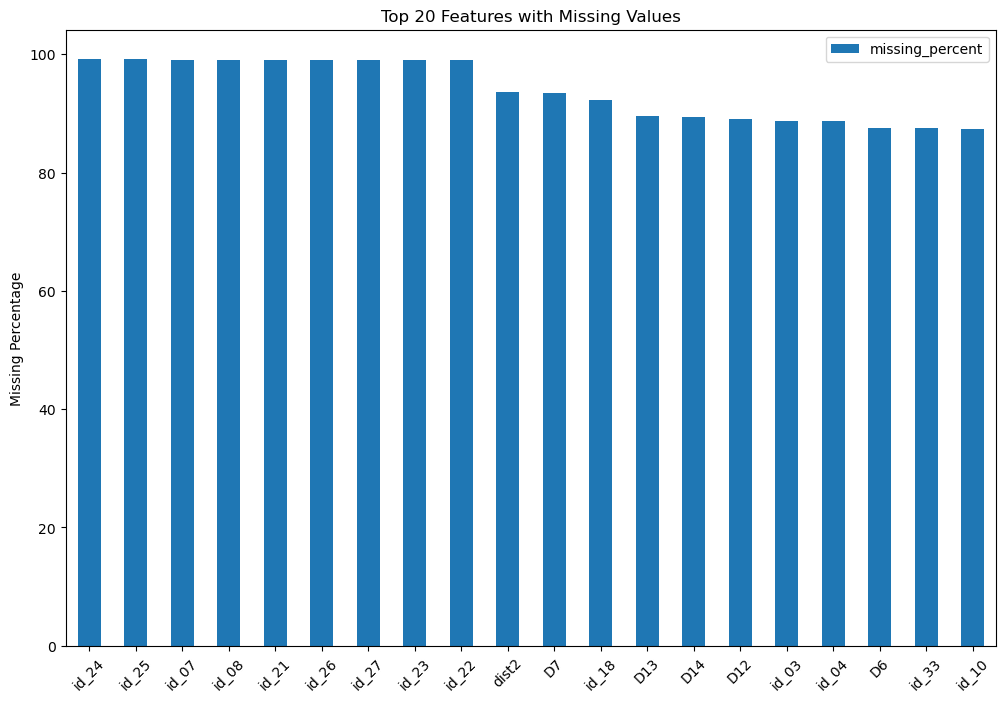

In [7]:
missing_df.head(20).plot(kind='bar')
plt.title("Top 20 Features with Missing Values")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45)
plt.show()

## Features with Extremely High-Missing Values

We identify features with more than 90% missing values.

These features are likely to be removed during preprocessing as they provide limited useful information.

In [8]:
cols_to_drop = missing_percent[missing_percent > 90].index
print("Columns with >90% missing:", len(cols_to_drop))
display(cols_to_drop)

Columns with >90% missing: 12


Index(['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23',
       'id_24', 'id_25', 'id_26', 'id_27'],
      dtype='object')

## Transaction Amount Distribution

We analyze the distribution of transaction amounts.

Observation:
The distribution is highly skewed, with most transactions having low values and a few huge outliers.

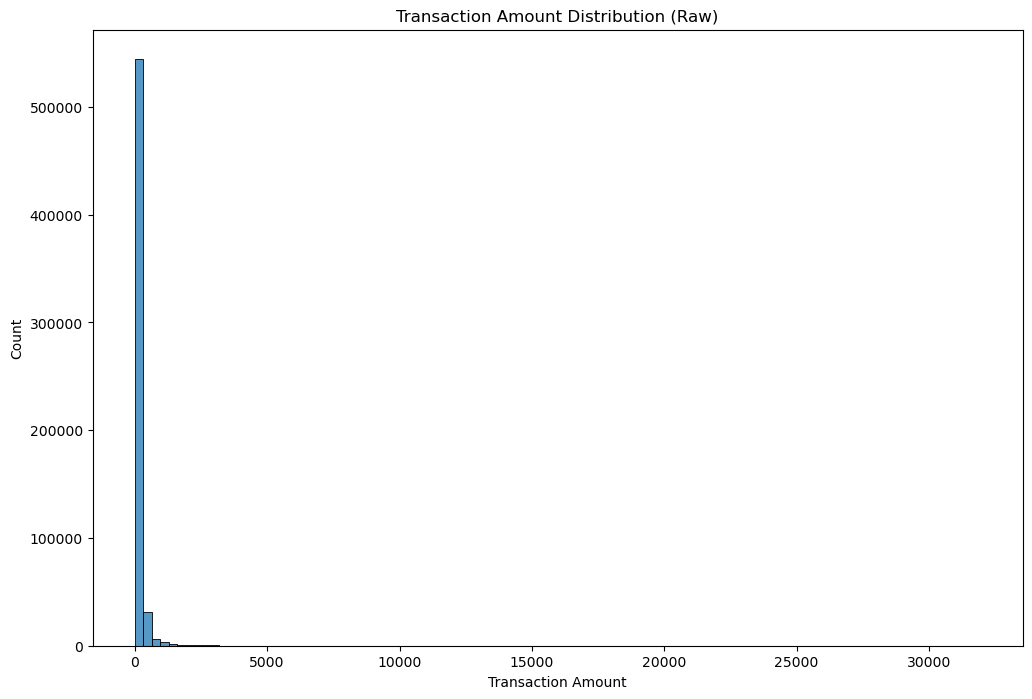

In [9]:
sns.histplot(df['TransactionAmt'], bins=100)
plt.title("Transaction Amount Distribution (Raw)")
plt.xlabel("Transaction Amount")
plt.show()

## Log Transformation of Transaction Amount

To reduce skewness, we apply a logarithmic transformation.

Observation:
The transformed distribution is more normalized, which can improve model performance.

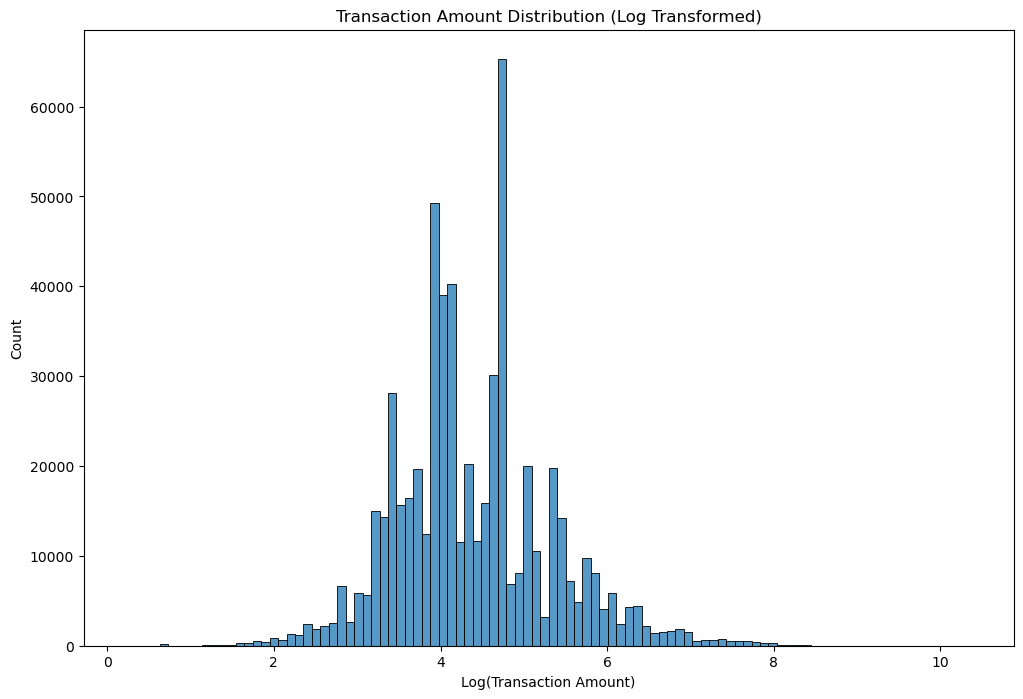

In [10]:
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

sns.histplot(df['TransactionAmt_log'], bins=100)
plt.title("Transaction Amount Distribution (Log Transformed)")
plt.xlabel("Log(Transaction Amount)")
plt.show()

## Transaction Amount vs. Fraud

We compare transaction amounts between fraudulent and non-fraudulent transactions.

Observation:
Fraudulent transactions tend to show different patterns, but there is still a significant overlap.

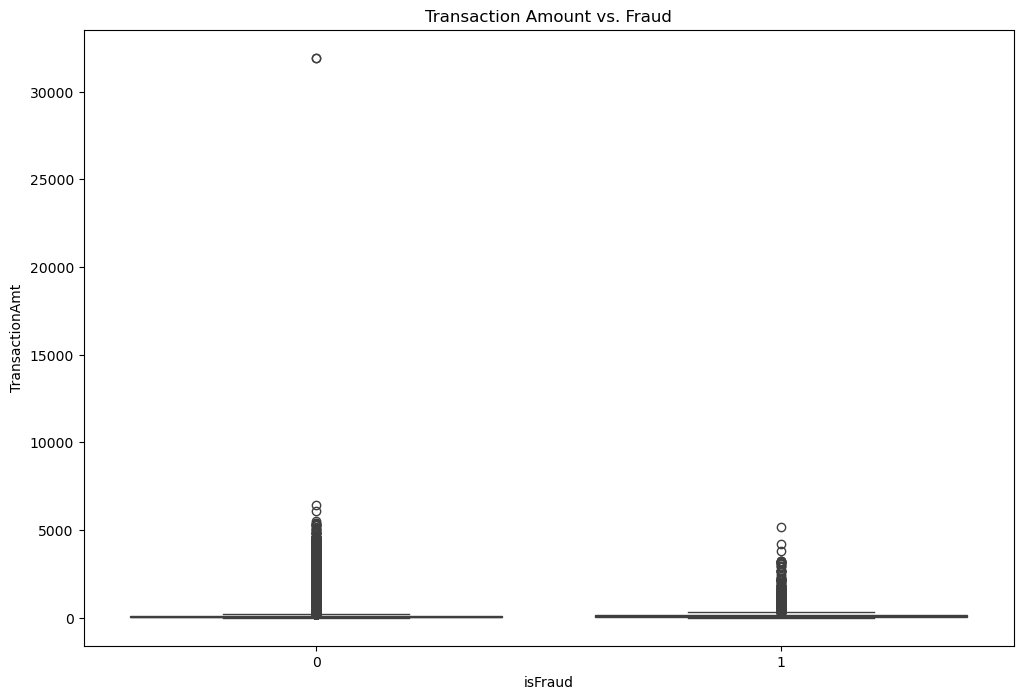

In [11]:
sns.boxplot(x='isFraud', y='TransactionAmt', data=df)
plt.title("Transaction Amount vs. Fraud")
plt.show()

## Product Category vs. Fraud

We analyze how different product categories relate to fraud occurrence.

Observation:
Some product categories appear to have higher fraud rates than others.

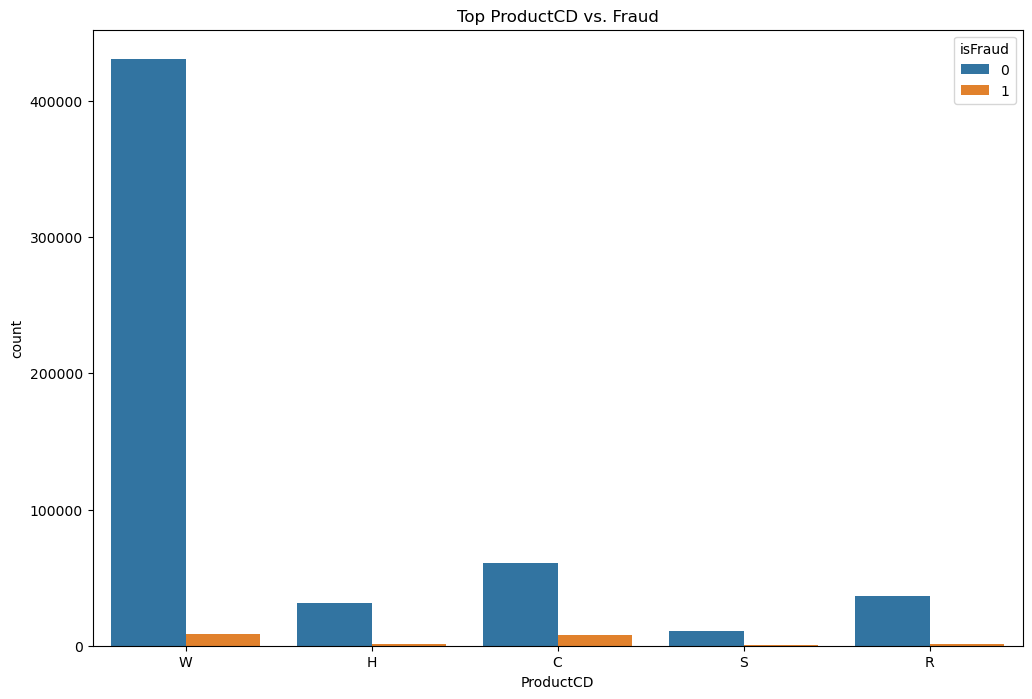

In [12]:
top_products = df['ProductCD'].value_counts().index[:5]
sns.countplot(data=df[df['ProductCD'].isin(top_products)], x='ProductCD', hue='isFraud')
plt.title("Top ProductCD vs. Fraud")
plt.show()

## Card Type vs. Fraud

We explore the relationship between card type and fraud.

Observation:
Certain card types may be more associated with fraudulent activity.

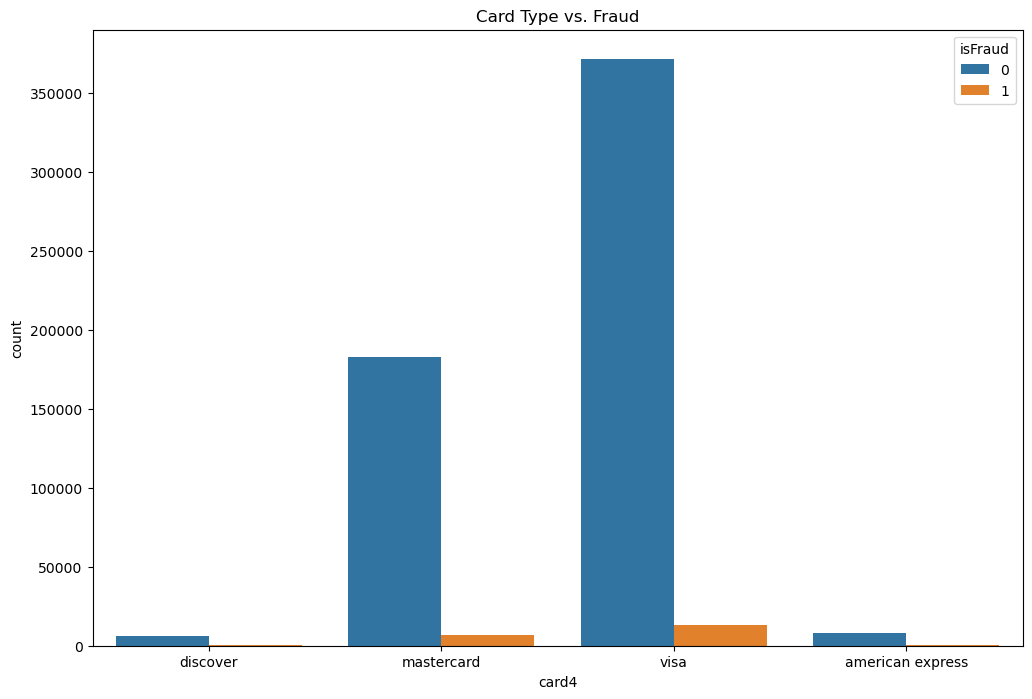

In [13]:
top_cards = df['card4'].value_counts().index[:5]
sns.countplot(data=df[df['card4'].isin(top_cards)], x='card4', hue='isFraud')
plt.title("Card Type vs. Fraud")
plt.show()

## Device Type vs. Fraud

We analyze whether the type of device used affects fraud likelihood.

Observation:
Fraud distribution may vary between device types.

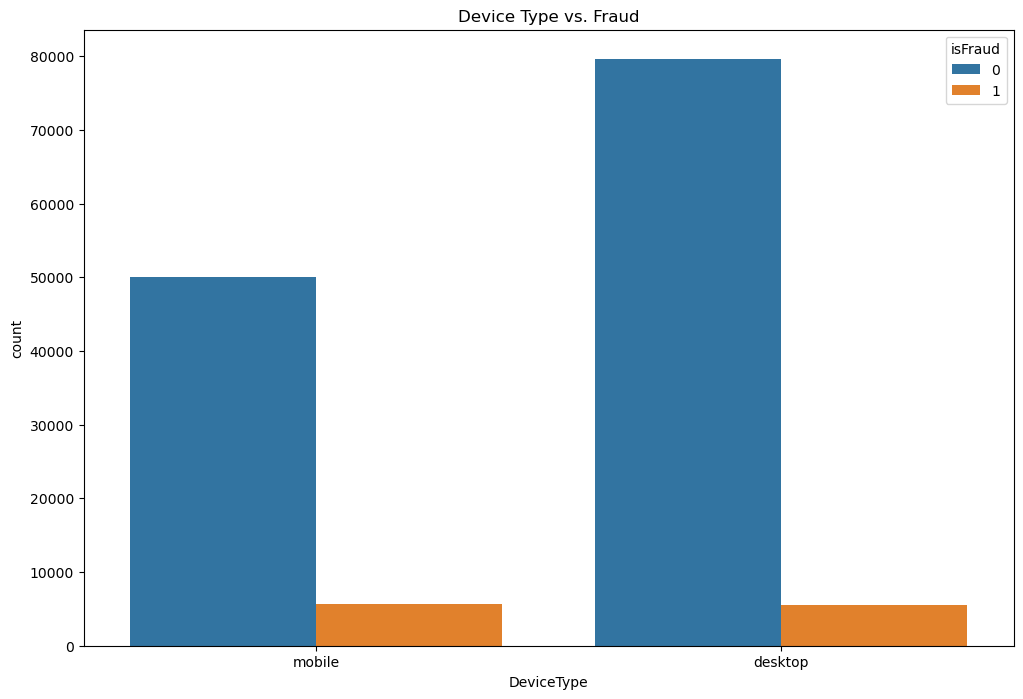

In [14]:
top_devices = df['DeviceType'].value_counts().index[:5]
sns.countplot(data=df[df['DeviceType'].isin(top_devices)], x='DeviceType', hue='isFraud')
plt.title("Device Type vs. Fraud")
plt.show()

## Fraud Rate Over Time

We analyze how the fraud rate changes over time using a smoothed trend.

Observation:
Fraud occurrence shows patterns over time, indicating potential temporal behavior.

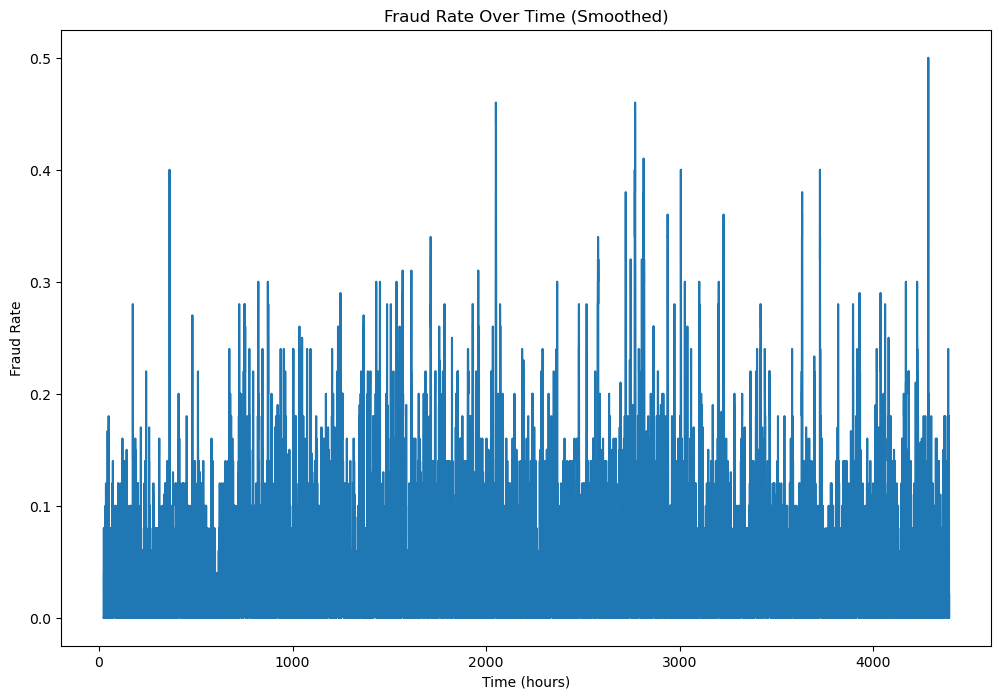

In [15]:
df['TransactionDT_hours'] = df['TransactionDT'] / 3600

df.groupby('TransactionDT_hours')['isFraud'] \
  .mean() \
  .rolling(50) \
  .mean() \
  .plot()

plt.title("Fraud Rate Over Time (Smoothed)")
plt.xlabel("Time (hours)")
plt.ylabel("Fraud Rate")
plt.show()

## Correlation with Target Variable

We compute correlations between numerical features and the target variable.

Observation:
Most features have weak individual correlation with fraud, suggesting that fraud detection depends on complex feature interactions.

isFraud    1.000000
V257       0.366163
V246       0.359459
V158       0.337192
V156       0.334262
V242       0.330641
V244       0.330090
V149       0.329344
V201       0.328246
V189       0.325194
V147       0.304148
V200       0.303329
V188       0.302511
V157       0.295150
V155       0.291266
Name: isFraud, dtype: float64

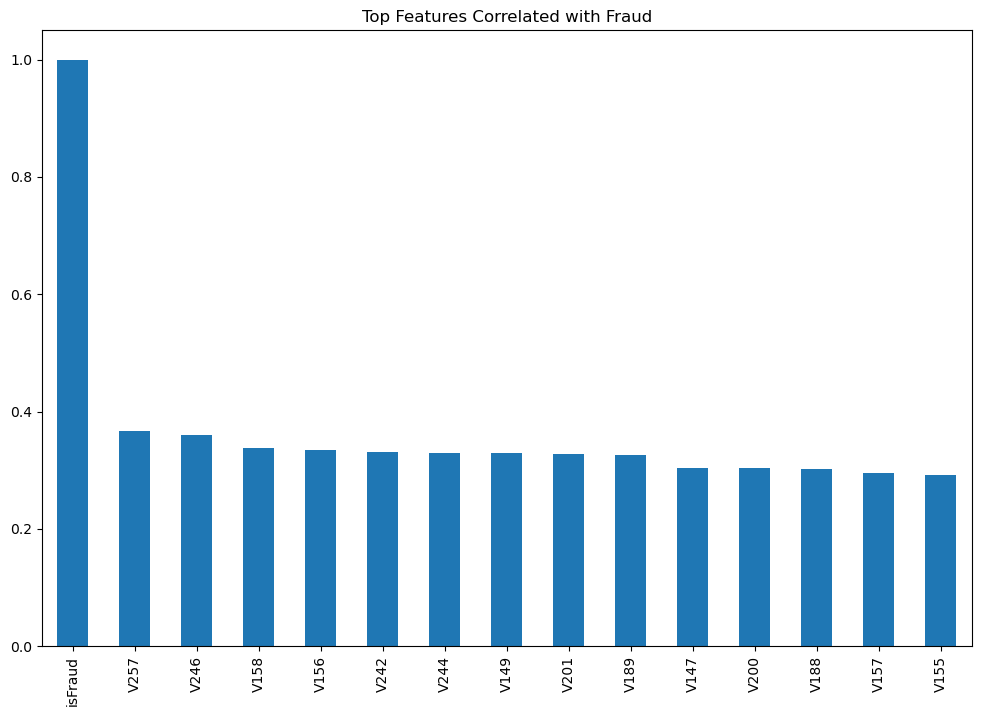

In [16]:
sample_df = df.sample(20000, random_state=42)

corr_target = sample_df.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)

display(corr_target.head(15))

corr_target.head(15).plot(kind='bar')
plt.title("Top Features Correlated with Fraud")
plt.show()

## Outlier Detection in Transaction Amount

We use a boxplot to detect outliers in transaction amounts.

Observation:
There are significant outliers that may affect model performance.

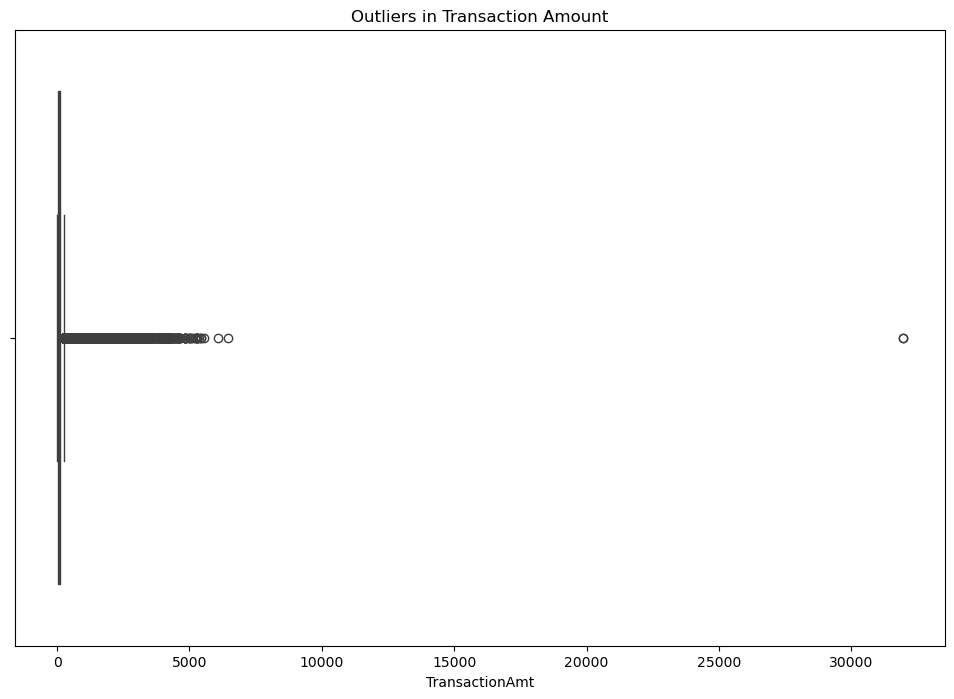

In [17]:
sns.boxplot(x=df['TransactionAmt'])
plt.title("Outliers in Transaction Amount")
plt.show()

## Transaction Amount Decimal Feature

We extract the decimal part of transaction amounts as a new feature.

This may capture subtle patterns in transaction behavior.

In [18]:
df['TransactionAmt_decimal'] = (
    (df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 1000
)

display(df[['TransactionAmt','TransactionAmt_decimal']].head())

,TransactionAmt,TransactionAmt_decimal
0,68.5,500.0
1,29.0,0.0
2,59.0,0.0
3,50.0,0.0
4,50.0,0.0


## Feature Type Analysis

We separate features into:
- Categorical features
- Numerical features

This is important for choosing appropriate preprocessing techniques.

In [19]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Number of categorical features:", len(cat_cols))
print("Number of numerical features:", len(num_cols))

Number of categorical features: 31
Number of numerical features: 406


## Key Insights

- The dataset is highly imbalanced with a small percentage of fraud cases
- Many features contain a high percentage of missing values
- Transaction amounts are highly skewed and benefit from log transformation
- Some categorical features show patterns related to fraud
- Fraud detection likely depends on complex interactions rather than single features

Conclusion:
The dataset requires careful preprocessing, including handling missing values, feature selection, and scaling before applying machine learning models.